In [10]:
!pip install geopandas rasterio xlrd
import os
import requests
import geopandas as gpd
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from rasterio.enums import Resampling 
from rasterio.mask import mask
from plot_functions import plot_boxplots, plot_distributions

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\melom\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# 🔥 Fire Dataset

### 👀 Data Visualisation

In [11]:
# dfAlg = pd.read_csv("Old_dataset/Fire/viirs-jpss1_alg_Tun.csv")

# print(dfAlg.head())

# # Convertir en GeoDataFrame
# gdfAlg = gpd.GeoDataFrame(
#     dfAlg,
#     geometry=gpd.points_from_xy(dfAlg.longitude, dfAlg.latitude),
#     crs="EPSG:4326"  # système de coordonnées géographiques standard (WGS84)
# )

# def download_naturalearth(output_folder="data"):

#     """Download Natural Earth shapefile if not present"""
#     os.makedirs(output_folder, exist_ok=True)
#     shapefile_path = os.path.join(output_folder, "ne_110m_admin_0_countries.shp")

#     if not os.path.exists(shapefile_path):
#         print("Downloading Natural Earth shapefile...")

#         url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
        
#         zip_path = os.path.join(output_folder, "ne_countries.zip")

#         r = requests.get(url)
#         with open(zip_path, "wb") as f:
#             f.write(r.content)

#         with zipfile.ZipFile(zip_path, "r") as zip_ref:
#             zip_ref.extractall(output_folder)
#         os.remove(zip_path)
#         print(" Natural Earth shapefile downloaded and extracted.")
#     else:
#         print(" Natural Earth shapefile already available.")
#     return shapefile_path

# # Charger la carte du monde et filtrer l'Algérie
# world = gpd.read_file(download_naturalearth())

# algeria = world[world["ADMIN"].isin(["Algeria", "Tunisia"])]



In [12]:
# dftun = pd.read_csv("../datasets/viirs-jpss1_2024_Tunisia.csv")
# print(dftun.head())

# # Convertir en GeoDataFrame
# gdfTun = gpd.GeoDataFrame(
#     dftun,
#     geometry=gpd.points_from_xy(dftun.longitude, dftun.latitude),
#     crs="EPSG:4326"  # système de coordonnées géographiques standard (WGS84)
# )

# # Charger la carte du monde et filtrer la Tunisie
# world = gpd.read_file(download_naturalearth())
# tunisie = world[world.ADMIN == "Tunisia"]

# # Tracer

# fig, ax = plt.subplots(figsize=(8, 10))
# algeria.plot(ax=ax, color="lightgray", edgecolor="black")

# gdfTun.plot(ax=ax, color="red", markersize=5)
# gdfAlg.plot(ax=ax, color="red", markersize=5)

# plt.title("VIIRS-JPSS1 2024 - Tunisia")
# plt.show()

### 🔎 Exploratory Data Analysis

In [13]:
df_fire = pd.read_csv("Old_dataset/Fire/viirs-jpss1_alg_Tun.csv")


In [14]:
print(df_fire.head())
print(df_fire.info())

df_fire.describe()

   latitude  longitude  bright_ti4  scan  track    acq_date  acq_time  \
0  36.79472    7.69950      296.12  0.45   0.39  2018-04-01       134   
1  36.59753    2.87901      304.70  0.39   0.36  2018-04-01       134   
2  36.62982    3.23120      304.06  0.39   0.36  2018-04-01       134   
3  36.33537    5.48419      302.92  0.40   0.37  2018-04-01       134   
4  36.74725    3.08371      297.85  0.39   0.36  2018-04-01       134   

  satellite instrument confidence  version  bright_ti5   frp daynight  type  \
0       N20      VIIRS          n        2      280.87  0.35        N     2   
1       N20      VIIRS          n        2      278.24  0.96        N     2   
2       N20      VIIRS          n        2      280.82  1.01        N     2   
3       N20      VIIRS          n        2      275.04  0.89        N     2   
4       N20      VIIRS          n        2      280.94  0.88        N     2   

   year  
0  2018  
1  2018  
2  2018  
3  2018  
4  2018  
<class 'pandas.core.frame.

,latitude,longitude,bright_ti4,scan,track,acq_time,version,bright_ti5,frp,type,year
count,649308.000000,649308.000000,649308.000000,649308.000000,649308.000000,649308.000000,649308.0,649308.000000,649308.000000,649308.000000,649308.000000
mean,31.683497,6.324358,323.149582,0.477940,0.520068,415.064255,2.0,292.560863,4.963944,1.633043,2021.057206
std,2.841932,2.620902,19.197587,0.102889,0.127054,500.844285,0.0,12.520425,11.788393,0.785146,1.942238
min,19.594900,-8.156330,207.930000,0.320000,0.360000,0.000000,2.0,232.470000,0.000000,0.000000,2018.000000
25%,28.734440,5.582580,306.130000,0.400000,0.400000,100.000000,2.0,283.290000,1.230000,2.000000,2019.000000
50%,31.644335,6.694570,319.940000,0.450000,0.500000,143.000000,2.0,291.500000,2.360000,2.000000,2021.000000
75%,32.951523,8.158320,339.400000,0.540000,0.620000,1139.000000,2.0,299.220000,4.880000,2.000000,2023.000000
max,37.329230,11.279690,367.000000,0.800000,0.780000,1416.000000,2.0,378.690000,1855.400000,3.000000,2024.000000


In [15]:
def diagnostiquer_outliers(df, colonne):
    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)
    IQR = Q3 - Q1
    seuil_bas = Q1 - 1.5 * IQR
    seuil_haut = Q3 + 1.5 * IQR
    
    # pourcentage d'outliers
    pourcentage = len(df[(df[colonne] < seuil_bas) | (df[colonne] > seuil_haut)]) / len(df) * 100
    
    # impact sur la moyenne
    impact_moyenne = df[colonne].mean() - df[colonne].median()
    
    # skewness
    skewness = df[colonne].skew()
    
    stats = {
        'pourcentage_outliers': pourcentage,
        'impact_moyenne': impact_moyenne,
        'skewness': skewness
    }
    return stats

import pandas as pd

# Créer un DataFrame pour stocker les statistiques
stats_list = []

for col in df_fire.select_dtypes(include=['int64', 'float64']).columns:
    stats = diagnostiquer_outliers(df_fire, col)
    stats['colonne'] = col
    stats_list.append(stats)

# Transformer en DataFrame
df_stats = pd.DataFrame(stats_list)
df_stats = df_stats[['colonne', 'pourcentage_outliers', 'impact_moyenne', 'skewness']]

# Affichage joli
pd.options.display.float_format = '{:.2f}'.format
print(df_stats)


       colonne  pourcentage_outliers  impact_moyenne  skewness
0     latitude                  0.00            0.04      0.41
1    longitude                  7.29           -0.37     -0.94
2   bright_ti4                  0.01            3.21      0.34
3         scan                  1.71            0.03      0.91
4        track                  0.00            0.02      0.38
5     acq_time                  0.00          272.06      1.03
6      version                  0.00            0.00      0.00
7   bright_ti5                  1.13            1.06      0.61
8          frp                  9.28            2.60     18.95
9         type                 19.21           -0.37     -1.56
10        year                  0.00            0.06     -0.00


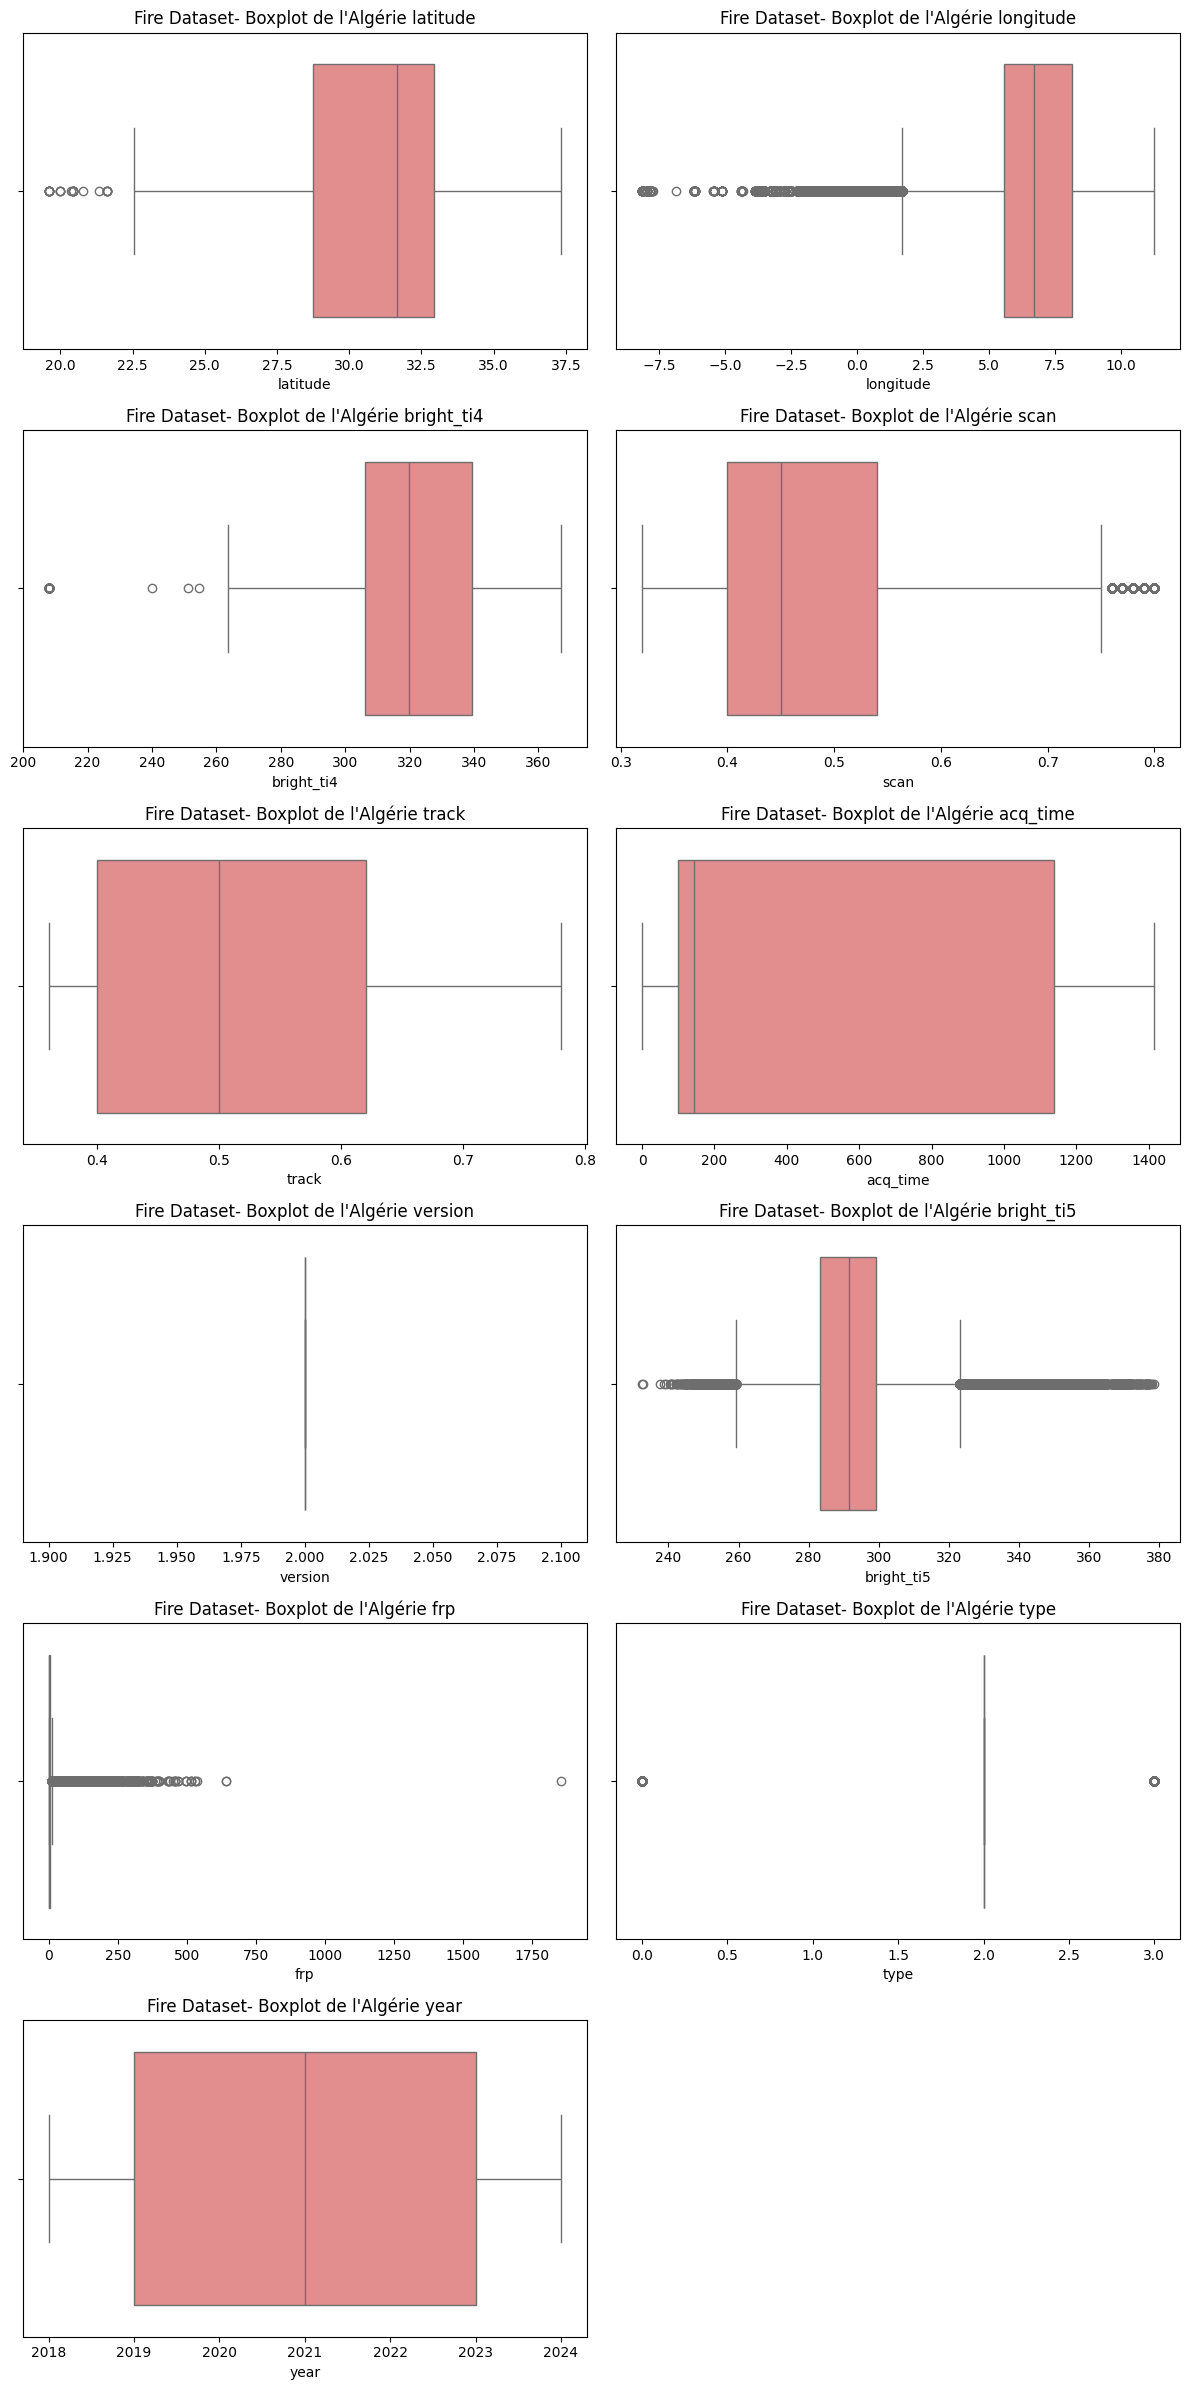

In [16]:
plot_boxplots(df_fire, title_prefix="Fire Dataset- Boxplot de l'Algérie", color='lightcoral')


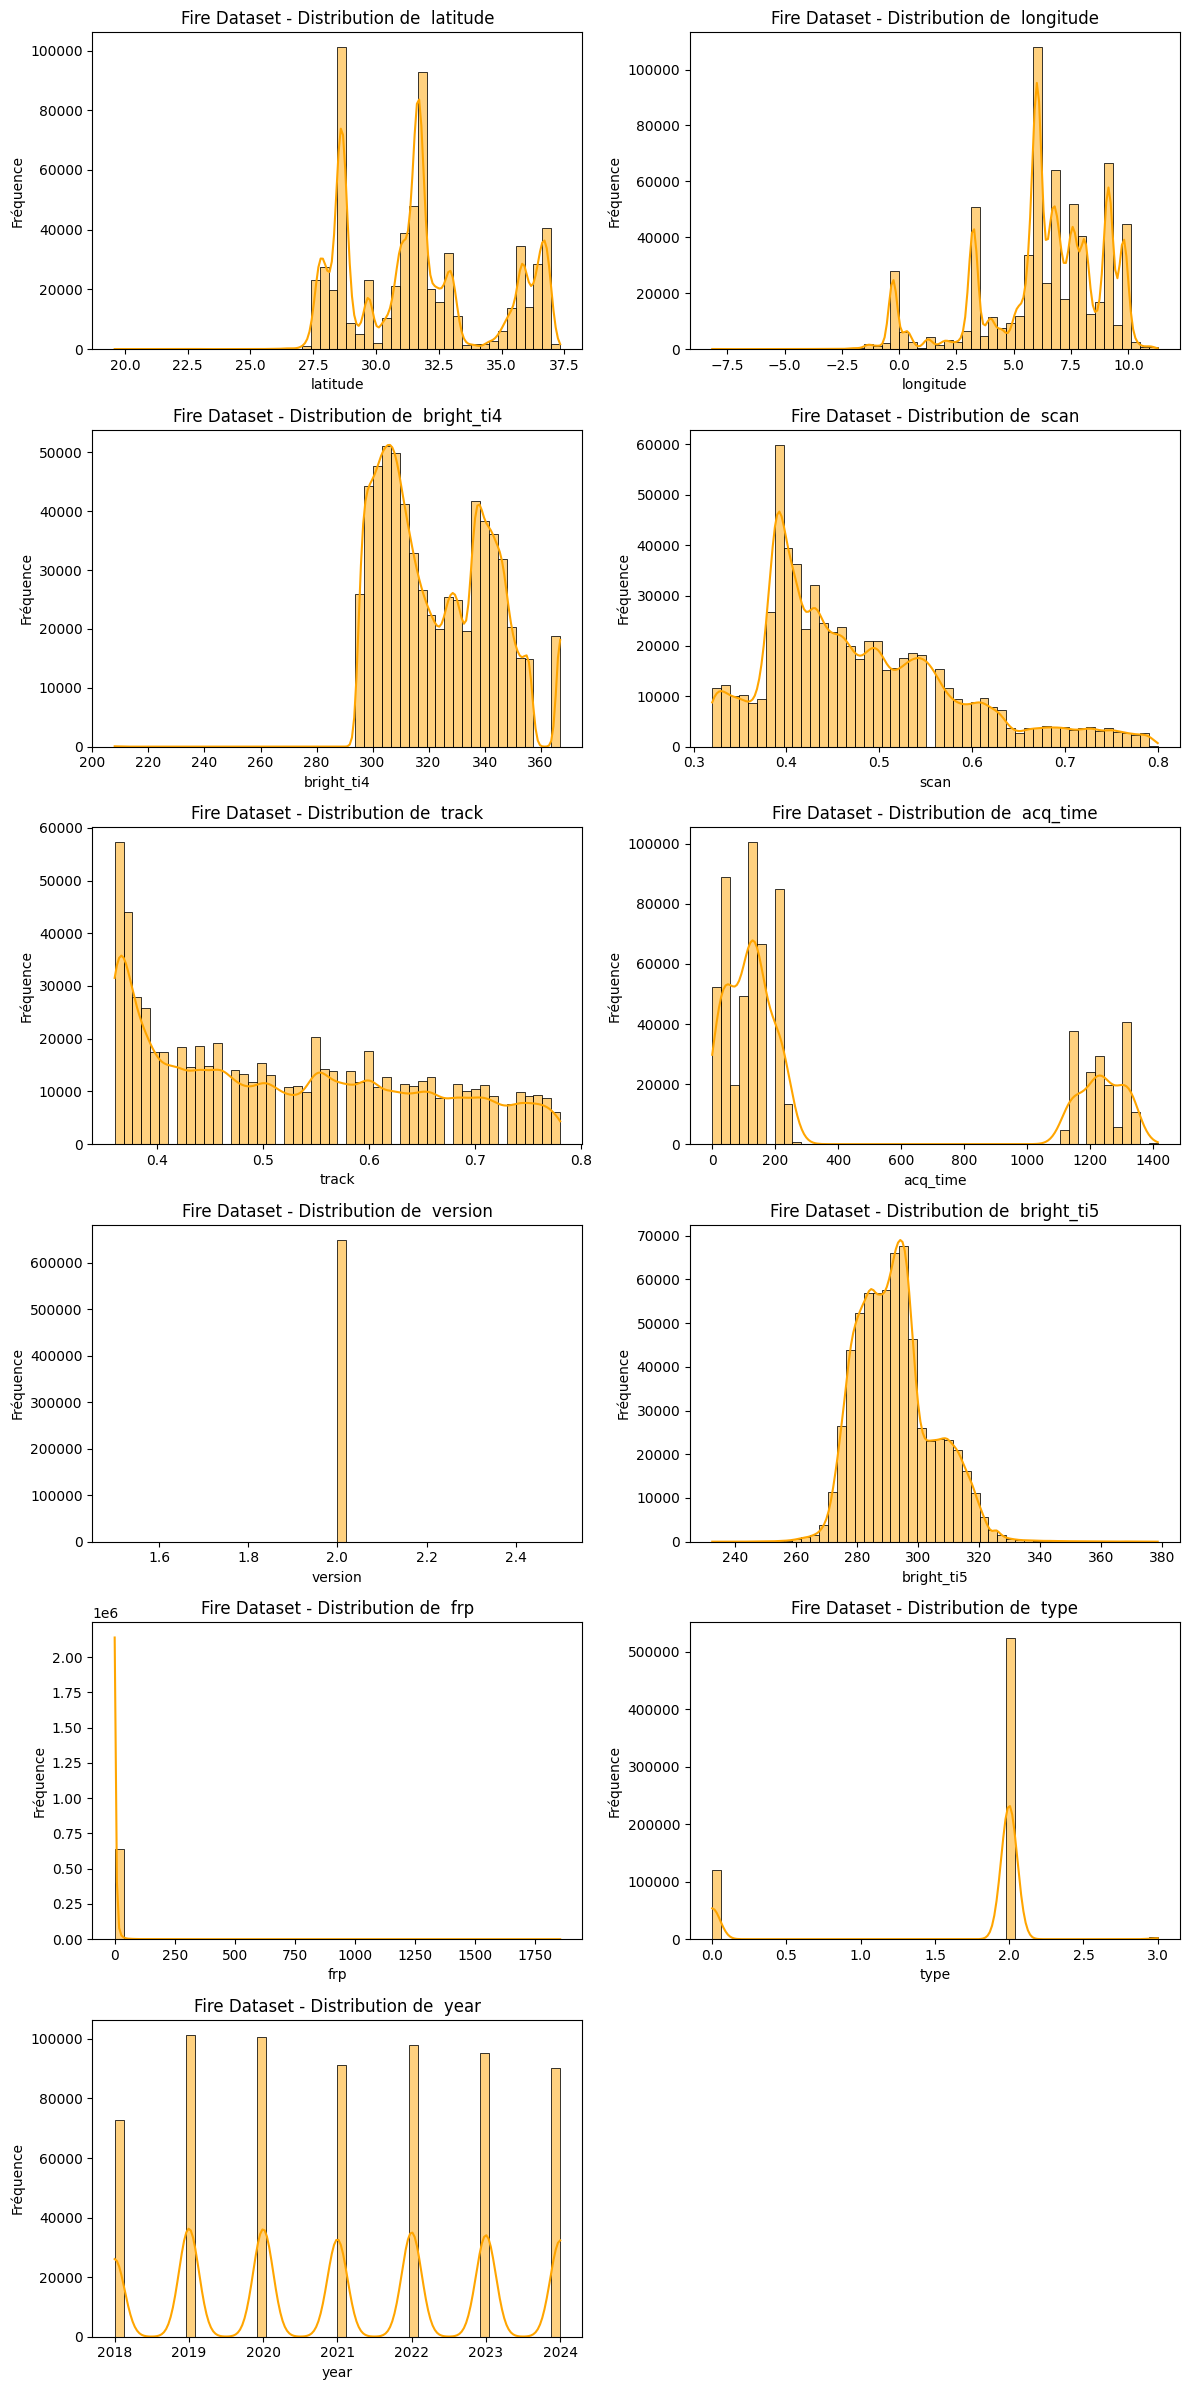

In [17]:
plot_distributions(df_fire, title_prefix="Fire Dataset - Distribution de ", color='orange')

C:\Users\melom\AppData\Local\Temp\ipykernel_12756\3211340704.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_fire, x=col, palette='viridis')
C:\Users\melom\AppData\Local\Temp\ipykernel_12756\3211340704.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_fire, x=col, palette='viridis')
C:\Users\melom\AppData\Local\Temp\ipykernel_12756\3211340704.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_fire, x=col, palette='viridis')
C:\Users\melom\AppData\Local\Temp\ipykernel_12756\3211340704.py:9: FutureWarning: 

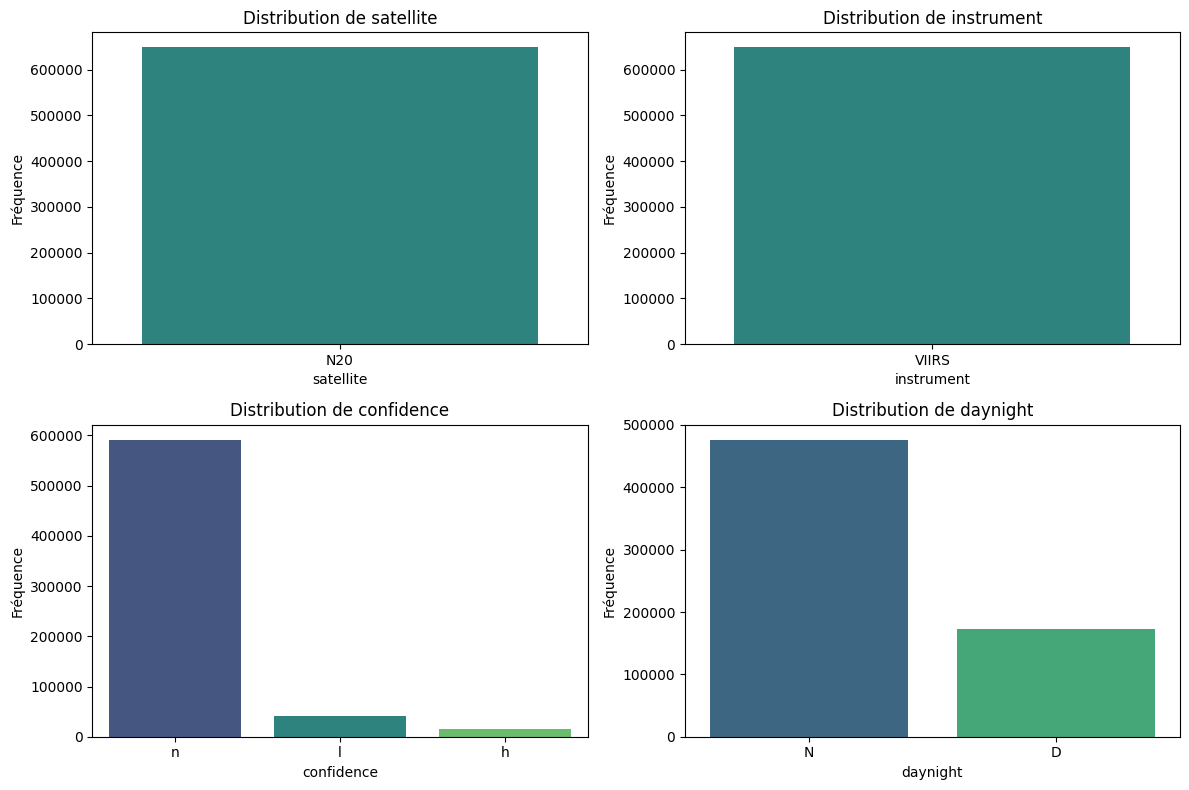

In [18]:
import seaborn as sns

cols = ['satellite', 'instrument', 'confidence', 'daynight']

plt.figure(figsize=(12, 8))  # taille globale de la figure

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)  # 2 lignes, 2 colonnes
    sns.countplot(data=df_fire, x=col, palette='viridis')
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")

plt.tight_layout()  # pour éviter le chevauchement
plt.show()


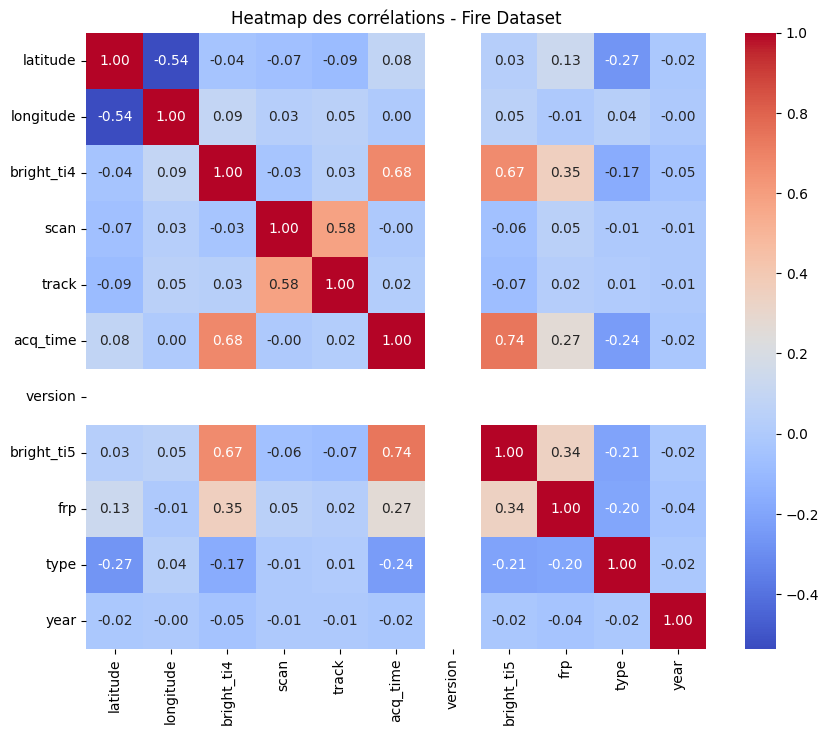

In [19]:
num_cols = df_fire.select_dtypes(include='number').columns

df_num = df_fire[num_cols]
# Calculer la matrice de corrélation
corr_matrix = df_num.corr()

# Afficher la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap des corrélations - Fire Dataset")
plt.show()

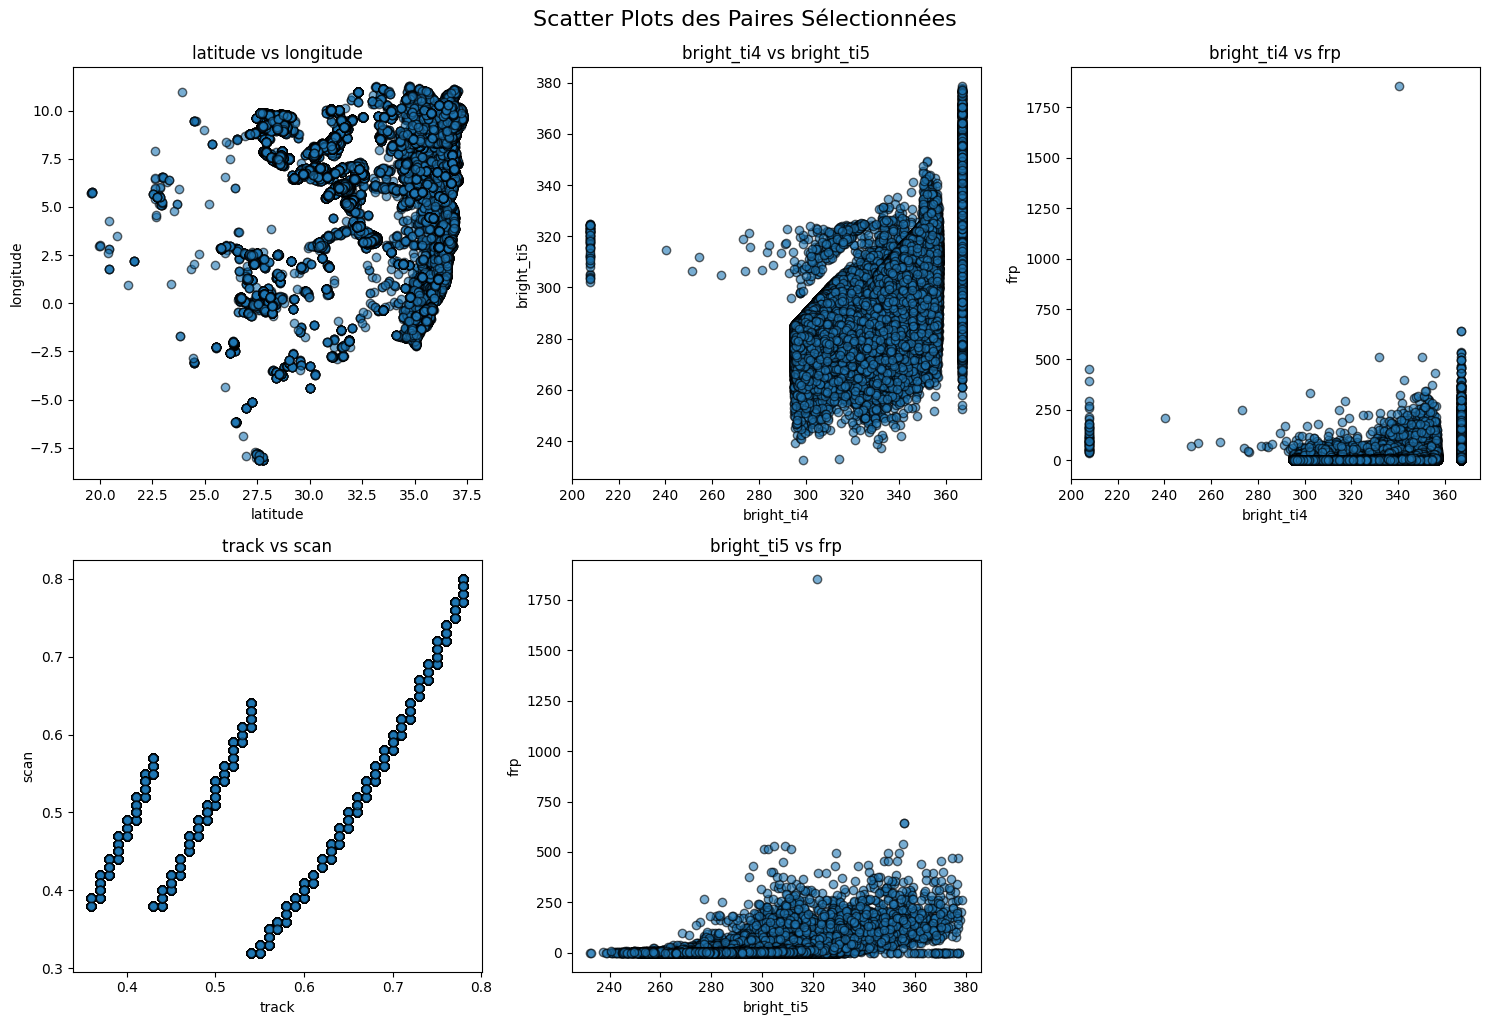

In [20]:

# Liste des paires à tracer
pairs = [
    ('latitude', 'longitude'),
    ('bright_ti4', 'bright_ti5'),
    ('bright_ti4', 'frp'),
    ('track', 'scan'),
    ('bright_ti5', 'frp')
]

# Définir la grille

plt.figure(figsize=(15, 10))

for i, (x, y) in enumerate(pairs, 1):
    plt.subplot(2, 3, i)
    plt.scatter(df_fire[x], df_fire[y], alpha=0.6, edgecolor='k')
    plt.xlabel(x)
    plt.ylabel(y)


    plt.title(f"{x} vs {y}")

plt.tight_layout()
plt.suptitle("Scatter Plots des Paires Sélectionnées", y=1.02, fontsize=16)
plt.show()


## 🧼 Cleaning and Pre-Processing

### 🗑️Deleting Columns with one value

In [21]:
df_fire_cleaned = df_fire.copy()
# Supprimer les colonnes avec une seule valeur unique
for col in df_fire_cleaned.columns:
    if df_fire_cleaned[col].nunique() == 1:
        df_fire_cleaned.drop(col, axis=1, inplace=True)

print("Colonnes après nettoyage :", df_fire_cleaned.columns)

Colonnes après nettoyage : Index(['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date',
       'acq_time', 'confidence', 'bright_ti5', 'frp', 'daynight', 'type',
       'year'],
      dtype='object')


In [22]:
df_fire_cleaned = df_fire_cleaned[df_fire_cleaned['type'] == 0].copy()

# Vérifier le résultat
print(df_fire_cleaned['type'].value_counts())
df_fire_cleaned.drop('type', axis=1, inplace=True)

type
0    120995
Name: count, dtype: int64


### 🛠️ Handling Outliers and Data Transformation

In [23]:
import numpy as np
def cyclical_encode_time(df, time_column='acq_time'):
    """
    Converts a time column (in HHMM format) into two cyclical features (sin and cos).
    
    Parameters:
    - df (pd.DataFrame): The input DataFrame.
    - time_column (str): The name of the column containing time in HHMM format.
    
    Returns:
    - pd.DataFrame: The DataFrame with the two new encoded columns added.
    """
    
    # --- 1. Convert HHMM to Total Minutes from Midnight ---
    # Example: 1430 -> 14 * 60 + 30 = 870 minutes
    
    # Extract hours (integer division by 100)
    hours = df[time_column] // 100
    
    # Extract minutes (modulo 100)
    minutes = df[time_column] % 100
    
    # Calculate total minutes from midnight
    df['total_minutes'] = (hours * 60) + minutes
    
    # The total number of minutes in a full cycle (24 hours)
    total_minutes_in_day = 24 * 60  # 1440

    # --- 2. Apply Sin and Cos Transformation ---
    
    # Calculate the sin component (Y-coordinate on the circle)
    df['time_sin'] = np.sin(2 * np.pi * df['total_minutes'] / total_minutes_in_day)
    
    # Calculate the cos component (X-coordinate on the circle)
    df['time_cos'] = np.cos(2 * np.pi * df['total_minutes'] / total_minutes_in_day)
    
    # --- 3. Clean up the Intermediate/Original Columns (Optional but Recommended) ---
    
    # Drop the intermediate 'total_minutes' and the original 'acq_time' column
    # because they are no longer needed and would confuse the model.
    df.drop(columns=['total_minutes', time_column], inplace=True)
    
    return df

# Example Usage (replace 'df' with your actual DataFrame name)
df_fire_cleaned = cyclical_encode_time(df_fire_cleaned, 'acq_time')
print(df_fire_cleaned.head())

    latitude  longitude  bright_ti4  scan  track    acq_date confidence  \
54     31.87       6.17      297.28  0.46   0.39  2018-04-01          n   
61     32.16       6.44      306.38  0.47   0.40  2018-04-01          n   
63     32.19       6.39      304.70  0.47   0.39  2018-04-01          n   
85     28.77       8.92      297.27  0.48   0.48  2018-04-01          n   
86     28.77       8.92      305.55  0.48   0.48  2018-04-01          n   

    bright_ti5  frp daynight  year  time_sin  time_cos  
54      277.23 0.94        N  2018      0.41      0.91  
61      281.00 1.34        N  2018      0.41      0.91  
63      281.07 0.91        N  2018      0.41      0.91  
85      279.18 0.37        N  2018      0.41      0.91  
86      278.81 0.88        N  2018      0.41      0.91  


In [24]:
import numpy as np
import pandas as pd

def winsorize_high_outliers(df, column):
    """
    Caps high-end outliers in a column using the 1.5 * IQR method (Winsorizing).
    
    Parameters:
    - df (pd.DataFrame): The input DataFrame.
    - column (str): The name of the column to treat (e.g., 'scan').
    
    Returns:
    - pd.DataFrame: The DataFrame with the treated column.
    """
    
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    # Calculate IQR
    IQR = Q3 - Q1
    
    # Calculate the Upper Fence (UF)
    # This is the cutoff point for defining an outlier
    upper_fence = Q3 + 1.5 * IQR
    
    # Cap the outliers: replace all values > UF with UF
    df[column] = np.where(
        df[column] > upper_fence,
        upper_fence,
        df[column]
    )
    
    print(f"✅ Outliers in '{column}' capped. Upper Boundary: {upper_fence:.4f}")
    
    return df

def winsorize_low_outliers(df, column):
    """
    Caps low-end outliers in a column using the 1.5 * IQR method (Winsorizing).
    
    Parameters:
    - df (pd.DataFrame): The input DataFrame.
    - column (str): The name of the column to treat.
    
    Returns:
    - pd.DataFrame: The DataFrame with the treated column.
    """
    
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    # Calculate IQR
    IQR = Q3 - Q1
    
    # Calculate the Lower Fence (LF)
    # This is the cutoff point for defining a low outlier
    lower_fence = Q1 - 1.5 * IQR
    
    # Cap the outliers: replace all values < LF with LF
    df[column] = np.where(
        df[column] < lower_fence,
        lower_fence,
        df[column]
    )
    
    print(f"✅ Low-end outliers in '{column}' capped. Lower Boundary: {lower_fence:.4f}")
    
    return df

# Example Usage (assuming your DataFrame is named 'df')
df_fire_cleaned = winsorize_high_outliers(df_fire_cleaned, 'scan')
df_fire_cleaned = winsorize_low_outliers(df_fire_cleaned, 'bright_ti4')
df_fire_cleaned = winsorize_low_outliers(df_fire_cleaned, 'bright_ti5')
df_fire_cleaned = winsorize_high_outliers(df_fire_cleaned, 'bright_ti5')



✅ Outliers in 'scan' capped. Upper Boundary: 0.7500


✅ Low-end outliers in 'bright_ti4' capped. Lower Boundary: 258.4850
✅ Low-end outliers in 'bright_ti5' capped. Lower Boundary: 257.5600
✅ Outliers in 'bright_ti5' capped. Upper Boundary: 337.9600


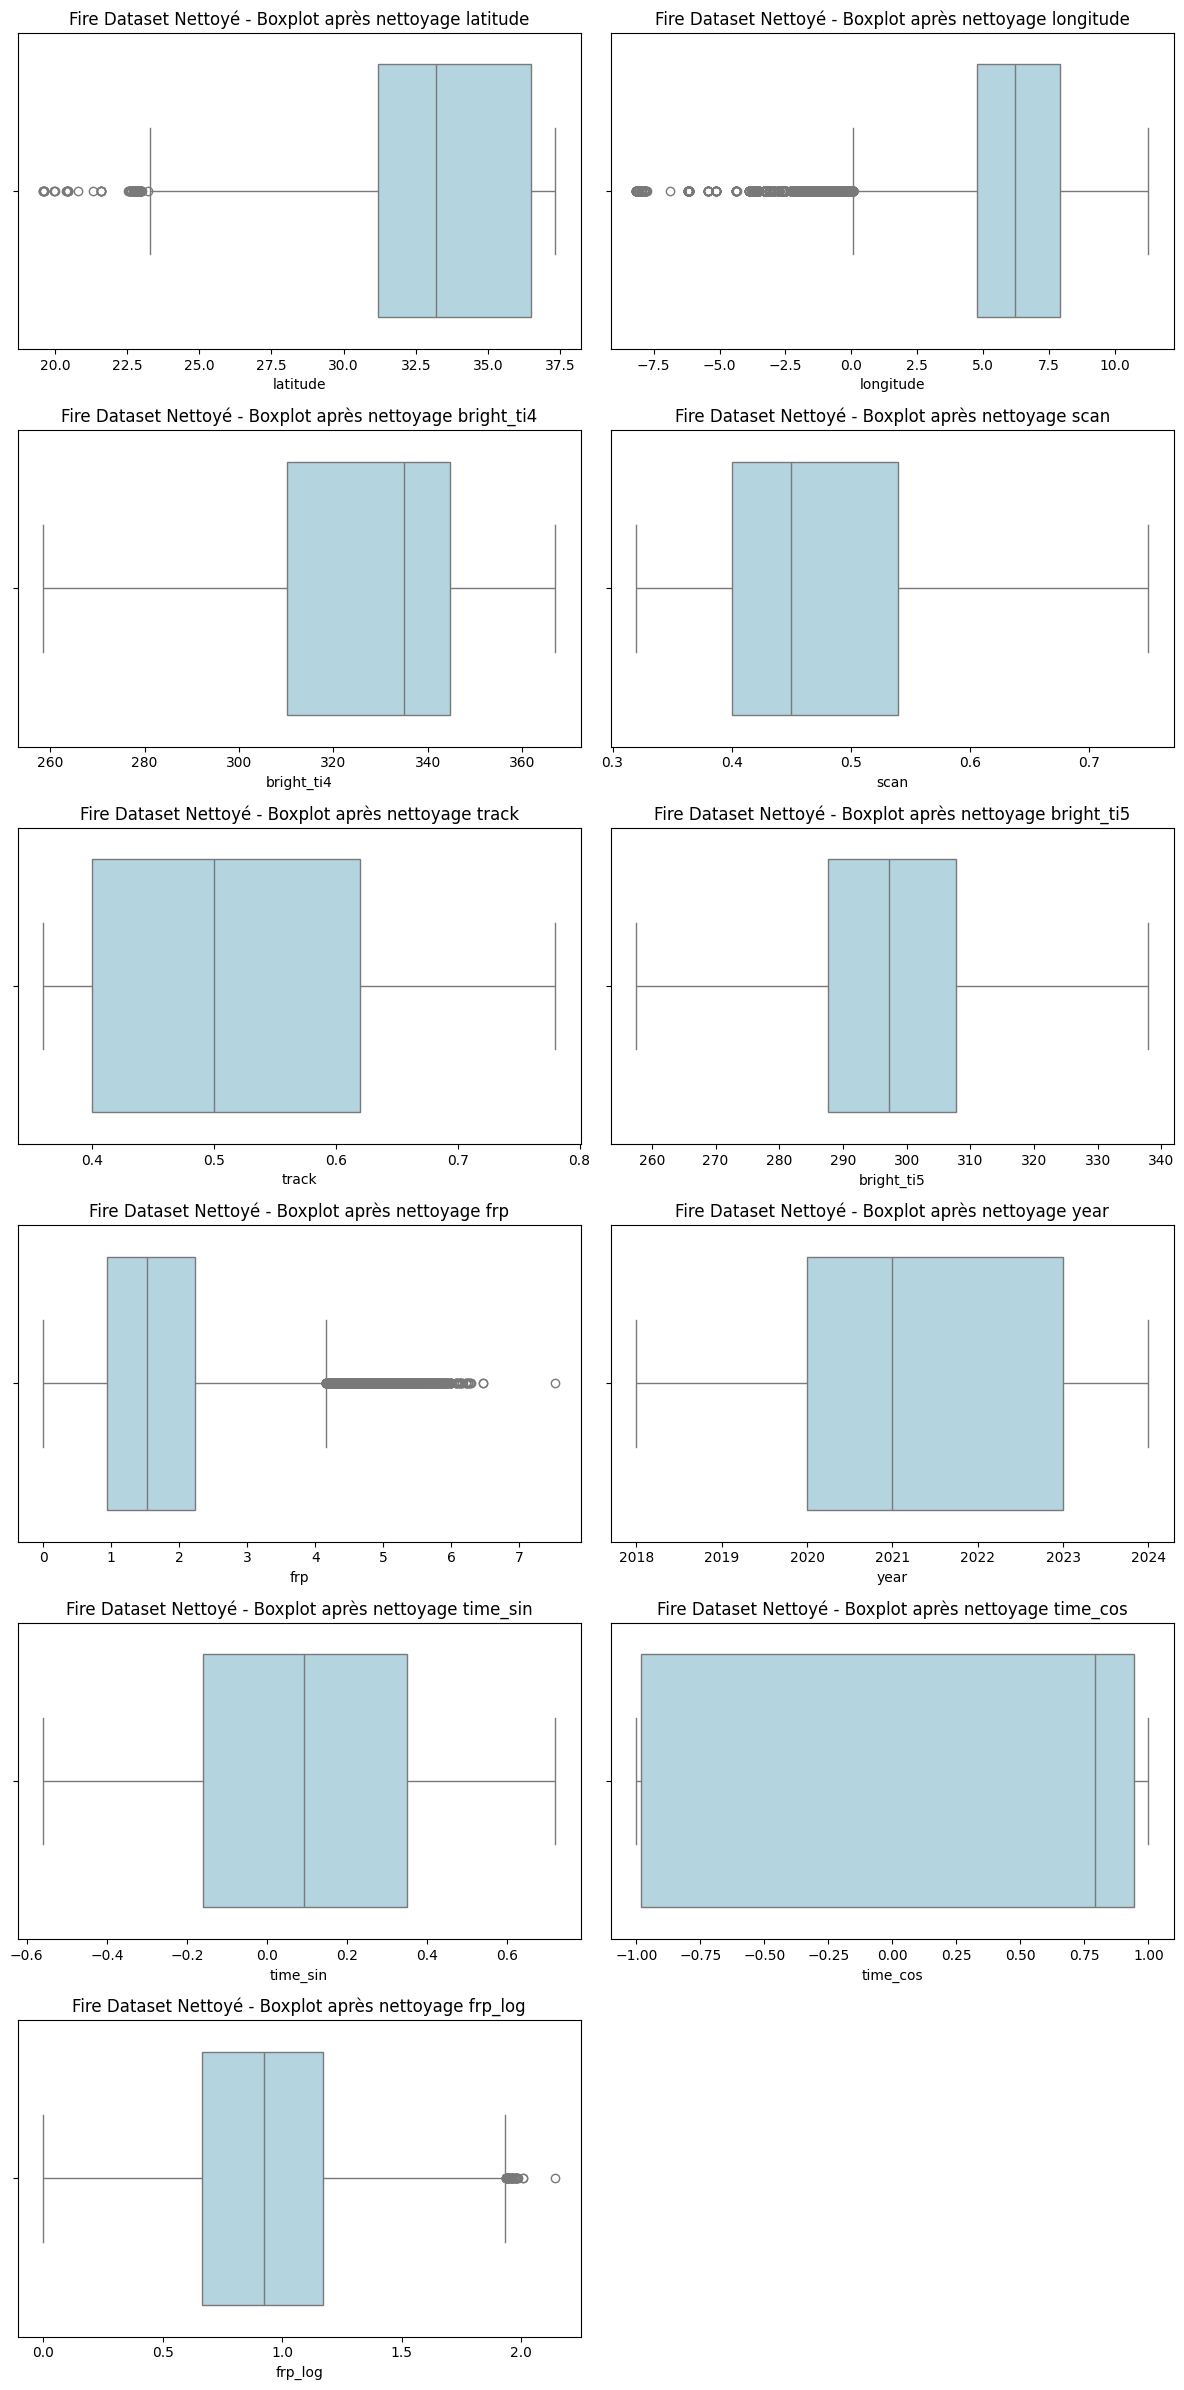

In [25]:

df_fire_cleaned['frp'] = np.log1p(df_fire_cleaned['frp'])  # log(1+x) pour gérer les zéros
df_fire_cleaned['frp_log'] = np.log(df_fire_cleaned['frp'] + 1)
plot_boxplots(df_fire_cleaned, title_prefix="Fire Dataset Nettoyé - Boxplot après nettoyage", color='lightblue')

In [26]:
from shapely.geometry import Point
import geopandas as gpd

# Convertir en GeoDataFrame APRÈS le nettoyage et AVANT la sauvegarde spatiale
geometry_fire = [Point(xy) for xy in zip(df_fire_cleaned['longitude'], df_fire_cleaned['latitude'])]
gdf_fire_cleaned = gpd.GeoDataFrame(df_fire_cleaned, geometry=geometry_fire, crs="EPSG:4326")

# Sauvegarde en GeoPackage
output_fire_path = 'Cleaned_dataset/Fire/cleaned_fire_data.gpkg'
gdf_fire_cleaned.to_file(output_fire_path, driver='GPKG')
print(f"gdf_fire_cleaned sauvegardé en {output_fire_path}")


gdf_fire_cleaned sauvegardé en Cleaned_dataset/Fire/cleaned_fire_data.gpkg
